# 20 — White-matter neuropil loss: stress test and microscopy

Notebooks 06 and 13: in white-matter (WM) lesions, the ATP1A1 signal in the 10 µm "territory" around each cell (the
non-cell space, i.e. neuropil: axon membranes, glial processes) is lower than in healthy WM of the same tissue piece
(×0.79 runs 5/6, ×0.72 runs 1–3). *Atp1a1* is not on the panel, so this would be tissue damage the transcriptome can't
show. Before calling it biology it gets the same stress test that withdrew the T-cell result (notebook 19):

1. **Reproduce** on all five runs, with the curated niches and the control-referenced lesion calls.
2. **Crowding.** Lesions are packed with infiltrating cells; the space around a cell is then smaller and shared with
   other cells' edges. (a) Compare lesion and healthy WM cells **at the same local cell density** in the same piece.
   (b) The territory pixel count and density as covariates. (c) **Control channels**: the same index for DAPI, 18S and
   αSMA/vimentin territory. Crowding would raise DAPI/18S around cells; a loss specific to ATP1A1 points to neuropil.
3. **Composition.** Compare the *same cell type* (astrocytes, MOL, microglia) in lesion vs healthy WM.
4. **Biology.** Is the loss deepest where myelin and myelinating oligodendrocytes are lost (lesion states, per piece)?
   Does it follow the lesion edge (lesion regions, notebook 16)?
5. **The tissue.** ATP1A1 channel alone: whole pieces with the lesion outline, and lesion vs healthy WM crops of the same
   piece side by side with DAPI to show cellularity (random pieces, same contrast within a piece).

Neuropil index (notebook 06): raw ATP1A1 territory mean ÷ the median of the same piece × region class (WM or GM).
Unit = tissue piece for paired lesion-vs-healthy comparisons (Wilcoxon over pieces), animal where noted.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import ndimage as ndi
from scipy.spatial import cKDTree
from scipy.stats import spearmanr, wilcoxon
from skimage.measure import find_contours

from beyondboundaries import data, plotting
from beyondboundaries.io import XeniumBundle, find_bundles

plotting.style()
SRC = "notebooks/20_neuropil_loss.ipynb"
OUT = ROOT / "results" / "20_neuropil_loss"
OUT.mkdir(parents=True, exist_ok=True)
COL = plotting.CATEGORICAL
PX = 0.2125
CH = data.CHANNELS
WM = ["WM", "WM_Meningeal"]
GM = ["GM", "DorsalHorn", "VentralHorn"]

In [2]:
a = ad.read_h5ad(ROOT / "data" / "RRMAP2_all_runs.h5ad", backed="r")
obs = a.obs[["sample_name", "meta_sample_id", "sample_id", "stage", "Anno_L1_curated", "Anno_L2",
             "Curated_niche_state", "Global_anatomical_region", "x_centroid", "y_centroid"]].copy()
a.file.close()
obs = obs.join(pd.read_parquet(ROOT / "data" / "lesion10" / "lesion_calls.parquet")[["lesion_state", "ctype"]])
obs = obs.join(pd.read_parquet(ROOT / "data" / "lesion16" / "regions.parquet"))
cols = ["section_id", "segmentation_method", "terr_npx", "centroid_x_px", "centroid_y_px"]
cols += [f"{c}_terr_mean" for c in CH] + [f"{c}_scale" for c in CH] + [f"{c}_bg_local" for c in CH]
cols += ["bnd_terr_p50", "bnd_terr_p90"]
fa = pd.read_parquet(ROOT / "data" / "features_norm_all.parquet", columns=cols)
fa = fa[fa.segmentation_method == "Segmented by interior stain (18S)"].join(obs, how="inner")
fa["run"] = fa.section_id.str.split("_").str[0]
fa["rclass"] = np.select([fa.Global_anatomical_region.isin(WM), fa.Global_anatomical_region.isin(GM)], ["WM", "GM"], "other")
fa = fa[fa.rclass != "other"]
for c in CH:
    fa[f"{c}_terr_raw"] = fa[f"{c}_terr_mean"] * fa[f"{c}_scale"] + fa[f"{c}_bg_local"]

# local density: cells (all annotated) within 20 µm, same piece; and pieces touching (runs 1-3) -> exclude borders
dens = pd.Series(np.nan, index=fa.index)
other = pd.Series(np.inf, index=fa.index)
for pc, g in obs.groupby("meta_sample_id", observed=True):
    f = fa.index.intersection(g.index)
    if len(f) == 0:
        continue
    t = cKDTree(g[["x_centroid", "y_centroid"]].to_numpy())
    dens[f] = [len(x) - 1 for x in t.query_ball_point(fa.loc[f, ["x_centroid", "y_centroid"]].to_numpy(), 20)]
for _, g in obs.groupby("sample_id", observed=True):
    xy, pcs = g[["x_centroid", "y_centroid"]].to_numpy(), g.meta_sample_id.astype(str).to_numpy()
    for p in np.unique(pcs):
        m = pcs == p
        if not m.all():
            idx = fa.index.intersection(g.index[m])
            if len(idx):
                other[idx] = cKDTree(xy[~m]).query(fa.loc[idx, ["x_centroid", "y_centroid"]].to_numpy())[0]
fa["density20"] = dens
fa = fa[other >= 20]

key = fa.meta_sample_id.astype(str) + "|" + fa.rclass
for c in CH:
    fa[f"{c}_index"] = fa[f"{c}_terr_raw"] / fa[f"{c}_terr_raw"].groupby(key).transform("median")
# ATP1A1 territory: diffuse background (median pixel) vs bright spots (90th percentile pixel)
for q in ["p50", "p90"]:
    raw = fa[f"bnd_terr_{q}"] * fa.bnd_scale + fa.bnd_bg_local
    fa[f"bnd{q}_index"] = raw / raw.groupby(key).transform("median")
fa["les_curated"] = fa.Curated_niche_state.astype(str).str.startswith("Lesion")
fa["phys_curated"] = fa.Curated_niche_state.astype(str) == "Physiological"
fa["les_ctrl"] = fa.lesion_state.str.startswith("S")
fa["phys_ctrl"] = fa.lesion_state == "no lesion"
print(len(fa), "18S-segmented WM/GM cells |", fa.run.value_counts().sort_index().to_dict())

1056046 18S-segmented WM/GM cells | {'run1': 205341, 'run2': 229092, 'run3': 246895, 'run5': 223312, 'run6': 151406}


## 1. Reproduce: lesion vs healthy WM within each piece

In [3]:
def paired(df, val, les, phys, rclass="WM", min_n=100, by="meta_sample_id"):
    rows = []
    d = df[df.rclass == rclass]
    for pc, g in d.groupby(by, observed=True):
        L, P = g[g[les]][val], g[g[phys]][val]
        if len(L) >= min_n and len(P) >= min_n:
            rows.append(dict(piece=pc, run=g.run.iloc[0], sample_name=g.sample_name.iloc[0], lesion=L.median(),
                             healthy=P.median()))
    r = pd.DataFrame(rows)
    if len(r) == 0:
        return r, {}
    r["ratio"] = r.lesion / r.healthy
    return r, dict(pieces=len(r), median_ratio=r.ratio.median(), share_below_1=(r.ratio < 1).mean(),
                   p=wilcoxon(r.lesion - r.healthy).pvalue)


rows = []
for les, phys, lab in [("les_curated", "phys_curated", "curated niches"), ("les_ctrl", "phys_ctrl", "control-referenced")]:
    for rc in ["WM", "GM"]:
        for c in CH:
            _, s = paired(fa, f"{c}_index", les, phys, rc)
            rows.append(dict(lesions=lab, region=rc, channel=plotting.CHANNEL_LABELS[c], **s))
rep = pd.DataFrame(rows)
rep.to_csv(OUT / "lesion_vs_healthy_by_channel.csv", index=False)
rep.pivot_table(index=["lesions", "region"], columns="channel", values="median_ratio").round(3)

channel                    18S rRNA  ATP1A1/CD45/E-Cad   DAPI  αSMA/Vimentin
lesions            region                                                   
control-referenced GM         1.008              1.028  1.062          1.499
                   WM         1.532              0.945  1.586          4.849
curated niches     GM         0.986              0.982  1.043          1.379
                   WM         1.011              0.731  1.157          5.158

Above: the median lesion ÷ healthy ratio per piece for each channel's territory signal. ATP1A1 is the neuropil
readout; DAPI, 18S and αSMA/vimentin are controls for crowding (more cells around → more nuclear and cytoplasmic signal
in the territory) and general brightness.

In [4]:
rep.pivot_table(index=["lesions", "region"], columns="channel", values="p").map(lambda v: f"{v:.1g}")

channel                   18S rRNA ATP1A1/CD45/E-Cad   DAPI αSMA/Vimentin
lesions            region                                                
control-referenced GM          0.2              0.06  9e-12         1e-12
                   WM        1e-19            0.0003  4e-20         3e-20
curated niches     GM        0.007              0.03  3e-10         5e-11
                   WM          0.4             3e-14  1e-10         2e-17

## 2. Crowding
**(a) Density-matched.** Within each piece, WM cells are binned by local density (cells within 20 µm; per-piece
quintiles); lesion vs healthy compared within each bin, then averaged over bins with ≥ 30 cells of each.

In [5]:
def density_matched(df, val, les, phys, min_n=30):
    rows = []
    d = df[df.rclass == "WM"].copy()
    d["dq"] = d.groupby("meta_sample_id", observed=True).density20.transform(
        lambda s: pd.qcut(s.rank(method="first"), 5, labels=False) if len(s) >= 50 else np.nan)
    for pc, g in d.groupby("meta_sample_id", observed=True):
        rat = []
        for q, h in g.groupby("dq"):
            L, P = h[h[les]][val], h[h[phys]][val]
            if len(L) >= min_n and len(P) >= min_n:
                rat.append(L.median() / P.median())
        if rat:
            rows.append(dict(piece=pc, run=g.run.iloc[0], ratio=np.mean(rat), bins=len(rat)))
    r = pd.DataFrame(rows)
    return r, dict(pieces=len(r), median_ratio=r.ratio.median(), share_below_1=(r.ratio < 1).mean(),
                   p=wilcoxon(r.ratio - 1).pvalue if len(r) >= 6 else np.nan)


rows = []
for les, phys, lab in [("les_curated", "phys_curated", "curated niches"), ("les_ctrl", "phys_ctrl", "control-referenced")]:
    for c in CH:
        _, s = density_matched(fa, f"{c}_index", les, phys)
        rows.append(dict(lesions=lab, channel=plotting.CHANNEL_LABELS[c], **s))
dm = pd.DataFrame(rows)
dm.to_csv(OUT / "density_matched.csv", index=False)
dm.round(3)

,lesions,channel,pieces,median_ratio,share_below_1,p
0,curated niches,DAPI,103,1.068,0.311,0.0
1,curated niches,ATP1A1/CD45/E-Cad,103,0.729,0.903,0.0
2,curated niches,18S rRNA,103,0.917,0.728,0.0
3,curated niches,αSMA/Vimentin,103,3.902,0.000,0.0
4,control-referenced,DAPI,119,1.145,0.126,0.0
5,control-referenced,ATP1A1/CD45/E-Cad,119,0.875,0.748,0.0
6,control-referenced,18S rRNA,119,1.190,0.151,0.0
7,control-referenced,αSMA/Vimentin,119,3.252,0.000,0.0


**(b) Covariates.** Per piece, the ATP1A1 index regressed on log density and log territory pixel count (WM cells),
then lesion vs healthy compared on the residuals. Plus: how much denser are lesion WM cells?

In [6]:
rows = []
for pc, g in fa[fa.rclass == "WM"].groupby("meta_sample_id", observed=True):
    g = g.dropna(subset=["bnd_index", "density20", "terr_npx"])
    L, P = g[g.les_curated], g[g.phys_curated]
    if len(L) < 100 or len(P) < 100:
        continue
    Z = np.c_[np.ones(len(g)), np.log1p(g.density20), np.log1p(g.terr_npx)]
    y = np.log(g.bnd_index.clip(lower=1e-3))
    res = pd.Series(y - Z @ np.linalg.lstsq(Z, y, rcond=None)[0], index=g.index)
    rows.append(dict(piece=pc, run=g.run.iloc[0], density_lesion=L.density20.median(), density_healthy=P.density20.median(),
                     terr_px_lesion=L.terr_npx.median(), terr_px_healthy=P.terr_npx.median(),
                     raw_ratio=L.bnd_index.median() / P.bnd_index.median(),
                     adjusted_ratio=float(np.exp(res[L.index].median() - res[P.index].median()))))
adj = pd.DataFrame(rows)
adj.to_csv(OUT / "covariate_adjusted.csv", index=False)
print(f"{len(adj)} pieces: lesion WM cells have {adj.density_lesion.median():.0f} vs {adj.density_healthy.median():.0f} "
      f"cells within 20 µm (median per piece); territory pixels {adj.terr_px_lesion.median():.0f} vs {adj.terr_px_healthy.median():.0f}")
print(f"ATP1A1 lesion ÷ healthy: raw {adj.raw_ratio.median():.3f} → adjusted for density + territory size "
      f"{adj.adjusted_ratio.median():.3f} (share < 1: {(adj.adjusted_ratio < 1).mean():.0%}, "
      f"Wilcoxon p = {wilcoxon(np.log(adj.adjusted_ratio)).pvalue:.2g})")

96 pieces: lesion WM cells have 3 vs 2 cells within 20 µm (median per piece); territory pixels 5018 vs 7100
ATP1A1 lesion ÷ healthy: raw 0.731 → adjusted for density + territory size 0.743 (share < 1: 88%, Wilcoxon p = 7.4e-14)


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/20_neuropil_loss/crowding_controls.png')

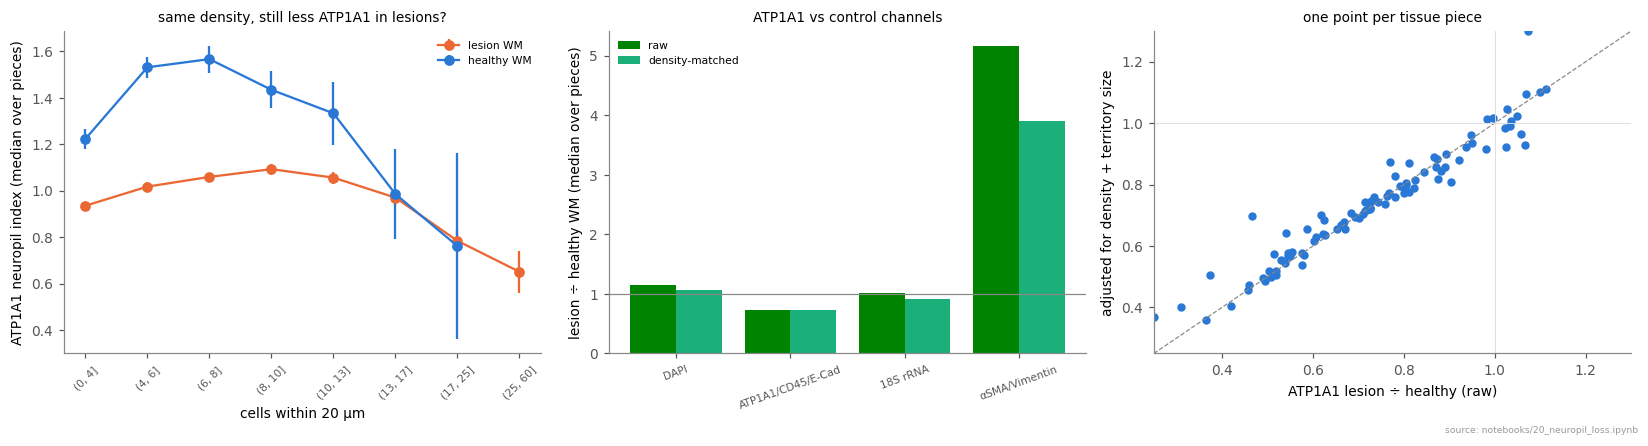

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
# (i) index vs density, WM, lesion vs healthy, pooled per density bin (median over pieces)
d = fa[fa.rclass == "WM"].copy()
d["dbin"] = pd.cut(d.density20, [0, 4, 6, 8, 10, 13, 17, 25, 60])
for les, lab, c in [("les_curated", "lesion WM", COL[1]), ("phys_curated", "healthy WM", COL[0])]:
    m = d[d[les]].groupby(["meta_sample_id", "dbin"], observed=True).bnd_index.median().unstack()
    axs[0].errorbar(range(m.shape[1]), m.median(), m.sem(), marker="o", color=c, label=lab)
axs[0].set_xticks(range(len(d.dbin.cat.categories)), [str(x) for x in d.dbin.cat.categories], rotation=45, fontsize=7)
axs[0].set(xlabel="cells within 20 µm", ylabel="ATP1A1 neuropil index (median over pieces)")
axs[0].legend(fontsize=7)
axs[0].set_title("same density, still less ATP1A1 in lesions?", fontsize=9)
# (ii) per-channel ratios (curated, WM), raw vs density-matched
r1 = rep[(rep.lesions == "curated niches") & (rep.region == "WM")].set_index("channel").median_ratio
r2 = dm[dm.lesions == "curated niches"].set_index("channel").median_ratio
x = np.arange(len(r1))
axs[1].bar(x - 0.2, r1.values, 0.4, color=COL[5], label="raw")
axs[1].bar(x + 0.2, r2.reindex(r1.index).values, 0.4, color=COL[2], label="density-matched")
axs[1].axhline(1, color="#888888", lw=0.8)
axs[1].set_xticks(x, r1.index, rotation=20, fontsize=7)
axs[1].set_ylabel("lesion ÷ healthy WM (median over pieces)")
axs[1].legend(fontsize=7)
axs[1].set_title("ATP1A1 vs control channels", fontsize=9)
# (iii) per piece raw vs adjusted
axs[2].scatter(adj.raw_ratio, adj.adjusted_ratio, s=20, color=COL[0])
lim = [min(adj[["raw_ratio", "adjusted_ratio"]].min().min(), 0.5), 1.3]
axs[2].plot(lim, lim, color="#888888", ls="--", lw=0.8)
axs[2].axhline(1, color="#dddddd", lw=0.6); axs[2].axvline(1, color="#dddddd", lw=0.6)
axs[2].set(xlabel="ATP1A1 lesion ÷ healthy (raw)", ylabel="adjusted for density + territory size", xlim=lim, ylim=lim)
axs[2].set_title("one point per tissue piece", fontsize=9)
fig.tight_layout()
plotting.save_fig(fig, "crowding_controls", OUT, SRC)

## 3. Same cell type, lesion vs healthy WM

In [8]:
rows = []
for t, m in [("Astrocyte", fa.Anno_L1_curated == "Astrocyte"), ("MOL", fa.Anno_L2 == "MOL"),
             ("Microglia", fa.Anno_L2 == "Microglia"), ("OPC/COP", fa.Anno_L2 == "OPC/COP"),
             ("Endothelial", fa.Anno_L1_curated == "Endothelial")]:
    _, s = paired(fa[m], "bnd_index", "les_curated", "phys_curated", "WM", min_n=20)
    _, s2 = paired(fa[m], "dapi_index", "les_curated", "phys_curated", "WM", min_n=20)
    rows.append(dict(cell_type=t, **{f"ATP1A1 {k}": v for k, v in s.items()}, **{"DAPI median_ratio": s2.get("median_ratio")}))
ct = pd.DataFrame(rows).set_index("cell_type")
ct.to_csv(OUT / "same_cell_type.csv")
ct.round(3)

,ATP1A1 pieces,ATP1A1 median_ratio,ATP1A1 share_below_1,ATP1A1 p,DAPI median_ratio
cell_type,,,,,
Astrocyte,90,0.739,0.878,0.0,1.083
MOL,101,0.740,0.891,0.0,0.919
Microglia,69,0.773,0.826,0.0,1.108
OPC/COP,64,0.863,0.719,0.0,1.034
Endothelial,84,0.665,0.917,0.0,1.151


## 4. Biology: where is the loss deepest?
(a) ATP1A1 index by control-referenced lesion state (WM, median over pieces with ≥ 50 cells of the state, healthy WM
of the piece = 1). (b) Per piece: depth of the loss vs local myelinating-oligodendrocyte loss (MOL share in lesion vs
healthy WM). (c) Across the edge of lesion regions (WM).

In [9]:
rows = []
wmc = fa[fa.rclass == "WM"]
for pc, g in wmc.groupby("meta_sample_id", observed=True):
    h = g[g.phys_ctrl].bnd_index
    if len(h) < 100:
        continue
    base = h.median()
    for st, s in g[g.les_ctrl].groupby(g[g.les_ctrl].lesion_state.str[:2]):
        if len(s) >= 50:
            rows.append(dict(piece=pc, state=st, ratio=s.bnd_index.median() / base,
                             dapi_ratio=s.dapi_index.median() / g[g.phys_ctrl].dapi_index.median(),
                             density_ratio=s.density20.median() / g[g.phys_ctrl].density20.median()))
bys = pd.DataFrame(rows)
bys.to_csv(OUT / "by_lesion_state.csv", index=False)
bys.groupby("state")[["ratio", "dapi_ratio", "density_ratio"]].median().join(bys.groupby("state").size().rename("pieces")).round(3)

,ratio,dapi_ratio,density_ratio,pieces
state,,,,
S0,0.855,1.006,1.000,98
S1,0.862,3.520,6.000,84
S2,1.006,1.592,2.500,112
S3,0.904,1.030,1.000,44
S4,0.948,1.634,2.500,91
S5,0.883,1.192,1.667,41


In [10]:
mol = obs.Anno_L2 == "MOL"
rows = []
for pc, g in obs[obs.Global_anatomical_region.isin(WM)].groupby("meta_sample_id", observed=True):
    L, P = g[g.lesion_state.str.startswith("S")], g[g.lesion_state == "no lesion"]
    if len(L) >= 200 and len(P) >= 200:
        rows.append(dict(piece=pc, mol_ratio=(L.Anno_L2 == "MOL").mean() / max((P.Anno_L2 == "MOL").mean(), 1e-3)))
molr = pd.DataFrame(rows).set_index("piece")
r_atp, _ = paired(fa, "bnd_index", "les_ctrl", "phys_ctrl", "WM")
bio = r_atp.set_index("piece").join(molr, how="inner")
rho = spearmanr(bio.ratio, bio.mol_ratio)
print(f"per piece (n = {len(bio)}): ρ(ATP1A1 lesion ÷ healthy, MOL share lesion ÷ healthy) = {rho.statistic:+.2f} (p = {rho.pvalue:.2g})")

per piece (n = 106): ρ(ATP1A1 lesion ÷ healthy, MOL share lesion ÷ healthy) = +0.25 (p = 0.01)


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/20_neuropil_loss/edge_profile.png')

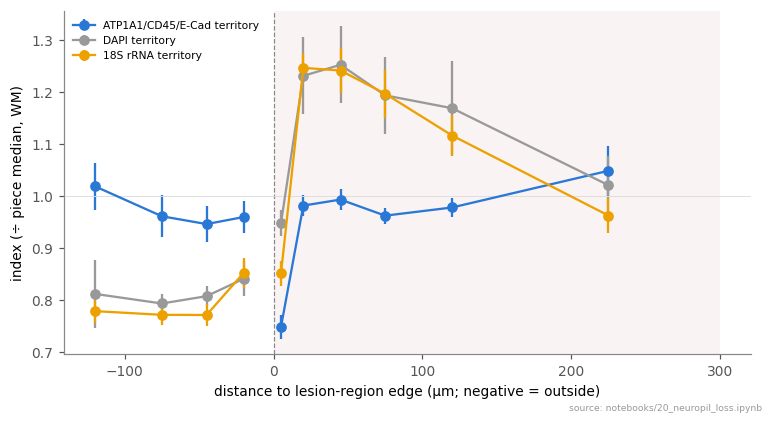

In [11]:
e = fa[(fa.rclass == "WM") & fa.reg_dist.notna()].copy()
e["ebin"] = pd.cut(e.reg_dist, [-150, -90, -60, -30, -10, 0, 10, 30, 60, 90, 150, 300])
mids = [-120, -75, -45, -20, -5, 5, 20, 45, 75, 120, 225]
fig, ax = plt.subplots(figsize=(7, 3.8))
for c, colr in [("bnd", COL[0]), ("dapi", "#999999"), ("r18s", COL[3])]:
    m = e.groupby(["meta_sample_id", "ebin"], observed=True)[f"{c}_index"].median().unstack().reindex(columns=e.ebin.cat.categories)
    ax.errorbar(mids, m.median(), m.sem(), marker="o", color=colr, label=plotting.CHANNEL_LABELS[c] + " territory")
ax.axvline(0, color="#888888", ls="--", lw=0.8); ax.axhline(1, color="#dddddd", lw=0.6)
ax.axvspan(0, 300, color="#f4e3e3", alpha=0.4, lw=0)
ax.set(xlabel="distance to lesion-region edge (µm; negative = outside)", ylabel="index (÷ piece median, WM)")
ax.legend(fontsize=7)
fig.tight_layout()
plotting.save_fig(fig, "edge_profile", OUT, SRC)

## 5. The tissue
**Whole pieces.** Four tissue pieces drawn at random (seed 0) from those with ≥ 300 WM lesion and ≥ 300 healthy WM
cells: the ATP1A1/CD45/E-cad channel alone (magma, 0.85 µm/px), WM lesion regions outlined in cyan.

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/20_neuropil_loss/pieces_atp1a1_with_wm_lesions.png')

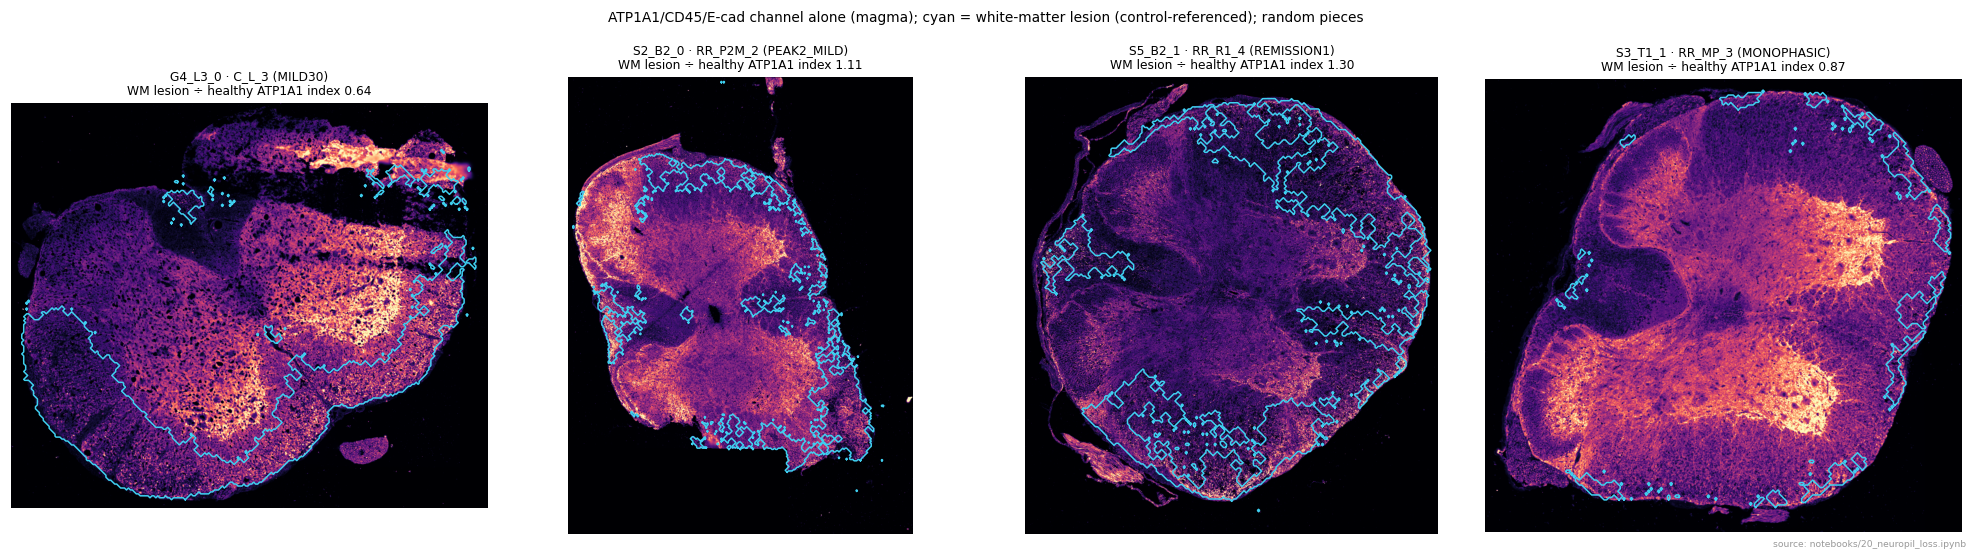

In [12]:
bundles = find_bundles(data.load_config())
elig = []
for pc, g in fa[fa.rclass == "WM"].groupby("meta_sample_id", observed=True):
    if g.les_ctrl.sum() >= 300 and g.phys_ctrl.sum() >= 300:
        elig.append(pc)
rng = np.random.default_rng(0)
pieces = list(rng.choice(sorted(elig), 4, replace=False))
_img = {}


def level_img(sec, ch, lv):
    k = (sec, ch, lv)
    if k not in _img:
        _img[k] = XeniumBundle(bundles[sec]).read_level(ch, lv)
    return _img[k]


def outline_cells(ax, cells, x0, y0, step=10.0, it=2, color="#3fd0f0"):
    if len(cells) == 0:
        return
    gx = ((cells.x_centroid - x0) / step).astype(int).to_numpy() + 1
    gy = ((cells.y_centroid - y0) / step).astype(int).to_numpy() + 1
    m = np.zeros((gy.max() + 3, gx.max() + 3), bool)
    m[gy, gx] = True
    m = ndi.binary_fill_holes(ndi.binary_closing(m, iterations=it))
    for cnt in find_contours(m.astype(float), 0.5):
        ax.plot(x0 + (cnt[:, 1] - 1) * step, y0 + (cnt[:, 0] - 1) * step, color=color, lw=1)


fig, axs = plt.subplots(1, 4, figsize=(18, 5))
lv, f = 2, 4
for ax, pc in zip(axs, pieces):
    g = obs[obs.meta_sample_id == pc]
    sec = str(g.sample_id.iloc[0])
    im = level_img(sec, "bnd", lv)
    pad = 40
    x0, x1 = g.x_centroid.min() - pad, g.x_centroid.max() + pad
    y0, y1 = g.y_centroid.min() - pad, g.y_centroid.max() + pad
    sl = (slice(max(int(y0 / (PX * f)), 0), int(y1 / (PX * f))), slice(max(int(x0 / (PX * f)), 0), int(x1 / (PX * f))))
    crop = im[sl]
    ax.imshow(np.clip(crop / np.percentile(crop[crop > 0], 99.5), 0, 1), cmap="magma", extent=(x0, x1, y1, y0))
    wl = g[g.Global_anatomical_region.isin(WM) & g.lesion_state.str.startswith("S")]
    outline_cells(ax, wl, x0, y0)
    r = r_atp.set_index("piece").ratio.get(pc, np.nan)
    ax.set_title(f"{pc} · {g.sample_name.iloc[0]} ({g.stage.iloc[0]})\nWM lesion ÷ healthy ATP1A1 index {r:.2f}", fontsize=8)
    ax.axis("off")
fig.suptitle("ATP1A1/CD45/E-cad channel alone (magma); cyan = white-matter lesion (control-referenced); random pieces",
             fontsize=9)
fig.tight_layout()
plotting.save_fig(fig, "pieces_atp1a1_with_wm_lesions", OUT, SRC)

**Lesion vs healthy white matter, same piece, side by side.** For the same four pieces: a 120 µm crop centred on a
random WM lesion cell and one centred on a random healthy WM cell (seed 0), ATP1A1 (top) and DAPI (bottom, showing
cellularity), identical contrast within each piece.

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/20_neuropil_loss/lesion_vs_healthy_wm_crops.png')

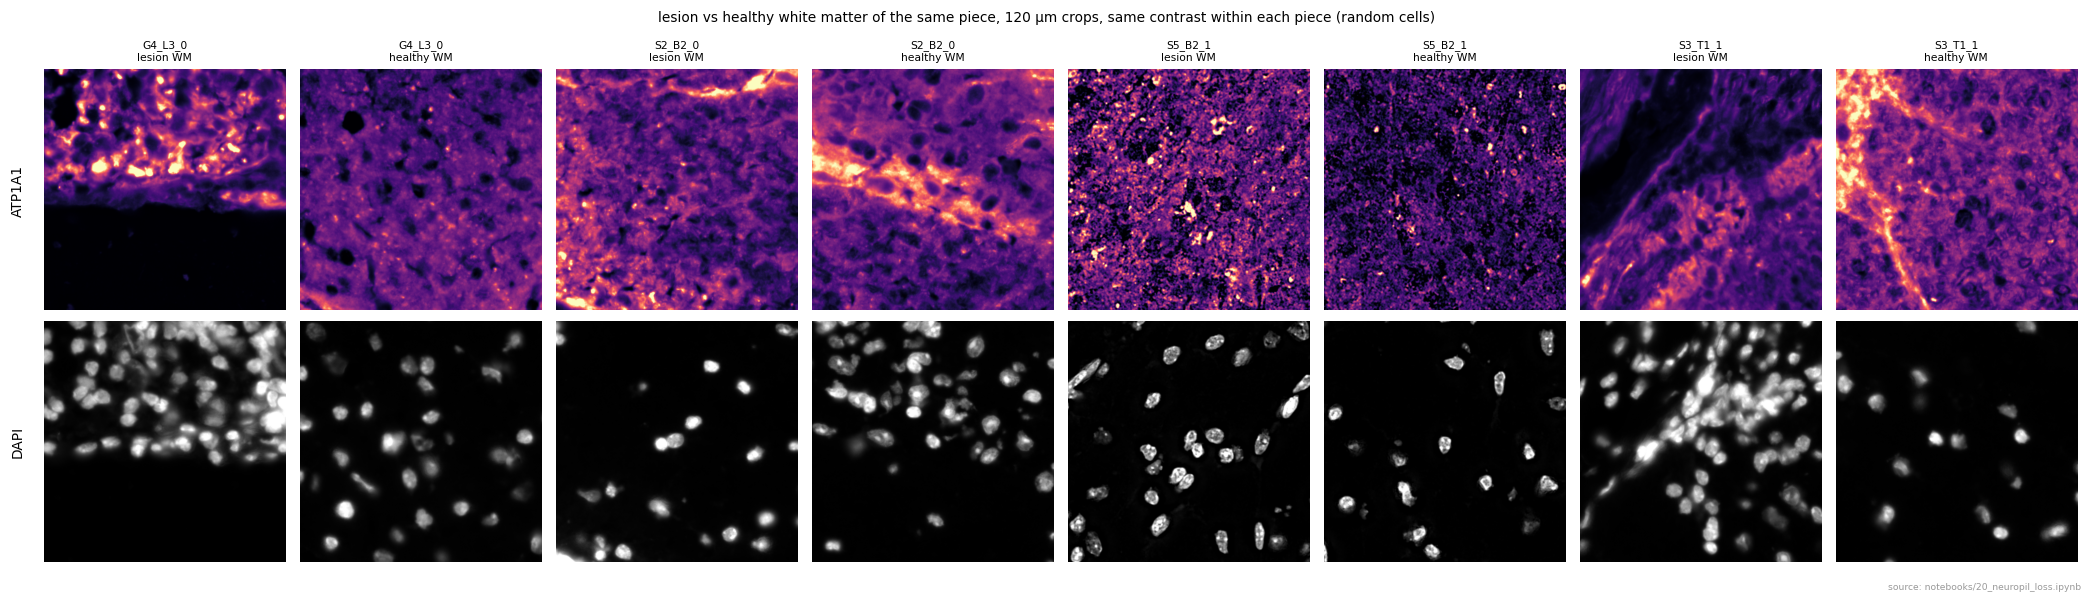

In [13]:
fig, axs = plt.subplots(2, 8, figsize=(19, 5.4))
half = 60
for k, pc in enumerate(pieces):
    g = fa[(fa.meta_sample_id == pc) & (fa.rclass == "WM")]
    sec = str(g.section_id.iloc[0])
    b = XeniumBundle(bundles[sec])
    crops = []
    for lab, m in [("lesion WM", g.les_ctrl), ("healthy WM", g.phys_ctrl)]:
        r = g[m].sample(1, random_state=0).iloc[0]
        h = int(half / PX)
        img, _, _ = b.read_window(int(r.centroid_y_px) - h, int(r.centroid_x_px) - h, 2 * h, 2 * h)
        crops.append((lab, img))
    hb = np.percentile(np.concatenate([c[1][1].ravel() for c in crops]), 99.5)
    hd = np.percentile(np.concatenate([c[1][0].ravel() for c in crops]), 99.5)
    for j, (lab, img) in enumerate(crops):
        col = 2 * k + j
        axs[0, col].imshow(np.clip(img[1] / hb, 0, 1), cmap="magma")
        axs[1, col].imshow(np.clip(img[0] / hd, 0, 1), cmap="gray")
        axs[0, col].set_title(f"{pc}\n{lab}", fontsize=7)
        for r_ in (0, 1):
            axs[r_, col].axis("off")
axs[0, 0].text(-0.08, 0.5, "ATP1A1", transform=axs[0, 0].transAxes, rotation=90, va="center", ha="right")
axs[1, 0].text(-0.08, 0.5, "DAPI", transform=axs[1, 0].transAxes, rotation=90, va="center", ha="right")
fig.suptitle("lesion vs healthy white matter of the same piece, 120 µm crops, same contrast within each piece (random cells)",
             fontsize=9)
fig.tight_layout()
plotting.save_fig(fig, "lesion_vs_healthy_wm_crops", OUT, SRC)

## 6. Tissue-surface confound
The edge profile shows ATP1A1 dips only in the first ~10 µm inside lesion regions, and the lesion interior is close
to 1. Many WM lesions are sub-pial. For a cell near the cord surface, part of its 10 µm territory lies outside the
tissue (dark background), pulling the territory mean down. That hits ATP1A1 hardest, because the neuropil signal exists
only inside tissue, while lesion crowding raises DAPI/18S and masks their own drop. Test: the same paired comparison
restricted to cells away from the tissue edge (distance to the tissue mask edge, notebook 02).

In [14]:
fa = fa.join(pd.read_parquet(ROOT / "data" / "features_norm_all.parquet", columns=["edge_um"]))
rows = []
for les, phys, lab in [("les_curated", "phys_curated", "curated niches"), ("les_ctrl", "phys_ctrl", "control-referenced")]:
    for lo in [0, 30, 50, 100, 200]:
        d = fa[fa.edge_um > lo]
        for c in ["bnd", "dapi", "r18s"]:
            _, s = paired(d, f"{c}_index", les, phys, "WM", min_n=50)
            _, s2 = density_matched(d, f"{c}_index", les, phys, min_n=20)
            rows.append(dict(lesions=lab, min_dist_from_surface=lo, channel=plotting.CHANNEL_LABELS[c],
                             pieces=s.get("pieces"), ratio=s.get("median_ratio"), share_below_1=s.get("share_below_1"),
                             p=s.get("p"), density_matched_ratio=s2.get("median_ratio")))
surf = pd.DataFrame(rows)
surf.to_csv(OUT / "surface_confound.csv", index=False)
surf.pivot_table(index=["lesions", "min_dist_from_surface"], columns="channel", values="ratio").round(3)

channel                                   18S rRNA  ATP1A1/CD45/E-Cad   DAPI
lesions            min_dist_from_surface                                    
control-referenced 0                         1.521              0.912  1.586
                   30                        1.584              0.953  1.609
                   50                        1.549              0.926  1.501
                   100                       1.462              0.883  1.449
                   200                       1.352              0.877  1.440
curated niches     0                         1.010              0.727  1.160
                   30                        1.031              0.751  1.179
                   50                        1.007              0.735  1.151
                   100                       0.927              0.737  1.075
                   200                       0.826              0.717  1.029

In [15]:
surf[surf.channel == "ATP1A1/CD45/E-Cad"].round(3)

,lesions,min_dist_from_surface,channel,pieces,ratio,share_below_1,p,density_matched_ratio
0,curated niches,0,ATP1A1/CD45/E-Cad,107,0.727,0.850,0.000,0.729
3,curated niches,30,ATP1A1/CD45/E-Cad,107,0.751,0.822,0.000,0.746
6,curated niches,50,ATP1A1/CD45/E-Cad,106,0.735,0.830,0.000,0.739
9,curated niches,100,ATP1A1/CD45/E-Cad,105,0.737,0.895,0.000,0.735
12,curated niches,200,ATP1A1/CD45/E-Cad,99,0.717,0.919,0.000,0.702
15,control-referenced,0,ATP1A1/CD45/E-Cad,121,0.912,0.645,0.000,0.875
18,control-referenced,30,ATP1A1/CD45/E-Cad,121,0.953,0.595,0.002,0.885
21,control-referenced,50,ATP1A1/CD45/E-Cad,120,0.926,0.600,0.000,0.872
24,control-referenced,100,ATP1A1/CD45/E-Cad,114,0.883,0.693,0.000,0.850
27,control-referenced,200,ATP1A1/CD45/E-Cad,104,0.877,0.769,0.000,0.845


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/20_neuropil_loss/surface_confound.png')

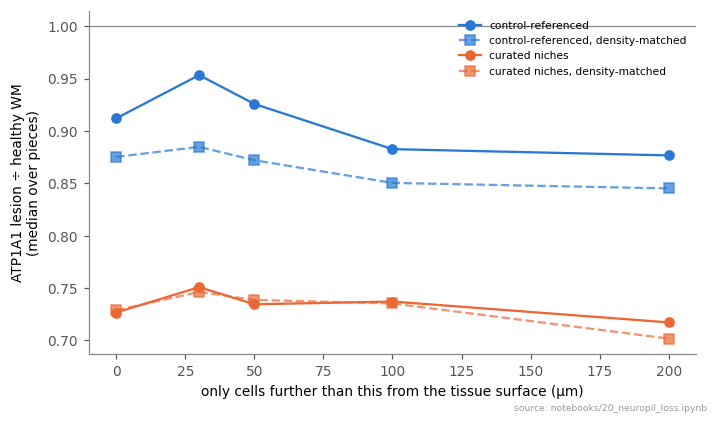

In [16]:
fig, ax = plt.subplots(figsize=(6.5, 3.8))
for k, (lab, g) in enumerate(surf[surf.channel == "ATP1A1/CD45/E-Cad"].groupby("lesions")):
    ax.plot(g.min_dist_from_surface, g.ratio, marker="o", color=COL[k], label=f"{lab}")
    ax.plot(g.min_dist_from_surface, g.density_matched_ratio, marker="s", ls="--", color=COL[k], alpha=0.7,
            label=f"{lab}, density-matched")
ax.axhline(1, color="#888888", lw=0.8)
ax.set(xlabel="only cells further than this from the tissue surface (µm)", ylabel="ATP1A1 lesion ÷ healthy WM\n(median over pieces)")
ax.legend(fontsize=7)
fig.tight_layout()
plotting.save_fig(fig, "surface_confound", OUT, SRC)

## Findings

> **Finding — white-matter neuropil loss holds up under every control.** ATP1A1 in the space around white-matter
> lesion cells is lower than around healthy WM cells of the same tissue piece: ×0.73 (curated lesions, 107 pieces,
> 85 % below 1), ×0.88–0.91 with the stricter control-referenced calls. It is **not crowding** (same at matched local
> density, ×0.73; adjusted for density and territory size ×0.74, 88 % of pieces, p = 7 × 10⁻¹⁴), **not lesion
> composition** (same cell type: astrocytes ×0.74, MOL ×0.74, microglia ×0.77, endothelium ×0.67), **not the tissue
> surface** (cells > 200 µm from the surface ×0.72, 92 % of 99 pieces; density-matched ×0.70), and **specific to
> ATP1A1** (DAPI and 18S around the same cells stay flat or rise, ×1.03–1.16; αSMA/vimentin rises ×4–5, reactive
> gliosis). It goes with myelinating-oligodendrocyte loss across pieces (ρ +0.25, p = 0.01) and is deepest in active and
> glial-reactive lesion states (×0.86) but absent in the late fibrotic state (×1.01).
>
> **Caveats.** The size depends on the lesion definition (−12 to −28 %). The dip at lesion-region edges is a
> tissue-surface artefact (territory partly outside the tissue) layered on top of the real loss. The effect is an
> average shift that varies between pieces, so it is **not obvious by eye in single random crops**; the per-piece
> paired comparisons are the evidence. The boundary channel also contains E-cadherin and CD45, but CD45 is undetectable
> in mouse cord (notebook 03) and E-cadherin is not expected in WM neuropil.

## 7. Anatomy confound: lesion vs *nearby* healthy white matter
WM tracts differ in ATP1A1 density (axon calibre and packing), and EAE lesions sit preferentially in some places
(sub-pial, ventral/lateral columns). Comparing lesion WM with *all* healthy WM of a piece could therefore partly
compare tracts. Local test: each WM lesion cell against the healthy WM cells of the same piece within 150 µm (median),
so the comparison stays within the same neighbourhood of white matter; lesion cells with ≥ 20 healthy WM cells in
that ring. Per piece: median of the per-cell local ratios. Also for deep cells only (> 100 µm from the surface).

In [17]:
def local_ratio(df, les, phys, radius=150, min_n=20, ch="bnd"):
    rows = []
    for pc, g in df[df.rclass == "WM"].groupby("meta_sample_id", observed=True):
        Lc, Hc = g[g[les]], g[g[phys]]
        if len(Lc) < 50 or len(Hc) < 50:
            continue
        t = cKDTree(Hc[["x_centroid", "y_centroid"]].to_numpy())
        nbrs = t.query_ball_point(Lc[["x_centroid", "y_centroid"]].to_numpy(), radius)
        hv = Hc[f"{ch}_index"].to_numpy()
        r = [lv / np.median(hv[n]) for lv, n in zip(Lc[f"{ch}_index"].to_numpy(), nbrs) if len(n) >= min_n]
        r = np.asarray(r)
        r = r[np.isfinite(r) & (r > 0)]
        if len(r) >= 30:
            rows.append(dict(piece=pc, cells=len(r), local_ratio=np.median(r)))
    d = pd.DataFrame(rows)
    return d, dict(pieces=len(d), median_local_ratio=d.local_ratio.median(), share_below_1=(d.local_ratio < 1).mean(),
                   p=wilcoxon(np.log(d.local_ratio)).pvalue if len(d) >= 6 else np.nan)


rows = []
for les, phys, lab in [("les_curated", "phys_curated", "curated niches"), ("les_ctrl", "phys_ctrl", "control-referenced")]:
    for depth in [0, 100]:
        d = fa[fa.edge_um > depth]
        for c in ["bnd", "dapi"]:
            _, s = local_ratio(d, les, phys, ch=c)
            rows.append(dict(lesions=lab, deeper_than_um=depth, channel=plotting.CHANNEL_LABELS[c], **s))
loc_tab = pd.DataFrame(rows)
loc_tab.to_csv(OUT / "local_vs_piecewide.csv", index=False)
loc_tab.round(3)

,lesions,deeper_than_um,channel,pieces,median_local_ratio,share_below_1,p
0,curated niches,0,ATP1A1/CD45/E-Cad,105,0.830,0.971,0.000
1,curated niches,0,DAPI,105,0.999,0.505,0.681
2,curated niches,100,ATP1A1/CD45/E-Cad,102,0.830,0.980,0.000
3,curated niches,100,DAPI,102,0.995,0.529,0.440
4,control-referenced,0,ATP1A1/CD45/E-Cad,109,0.984,0.596,0.204
5,control-referenced,0,DAPI,109,1.225,0.028,0.000
6,control-referenced,100,ATP1A1/CD45/E-Cad,104,0.967,0.721,0.000
7,control-referenced,100,DAPI,104,1.197,0.038,0.000


**Fair crops.** In the piece whose local ATP1A1 ratio is closest to the median: a deep WM lesion field and a healthy
WM field 150–300 µm away in the same white matter (both > 100 µm from the surface), ATP1A1 alone and DAPI, same
contrast; three such pairs from that piece.

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/20_neuropil_loss/fair_crops_local_pairs.png')

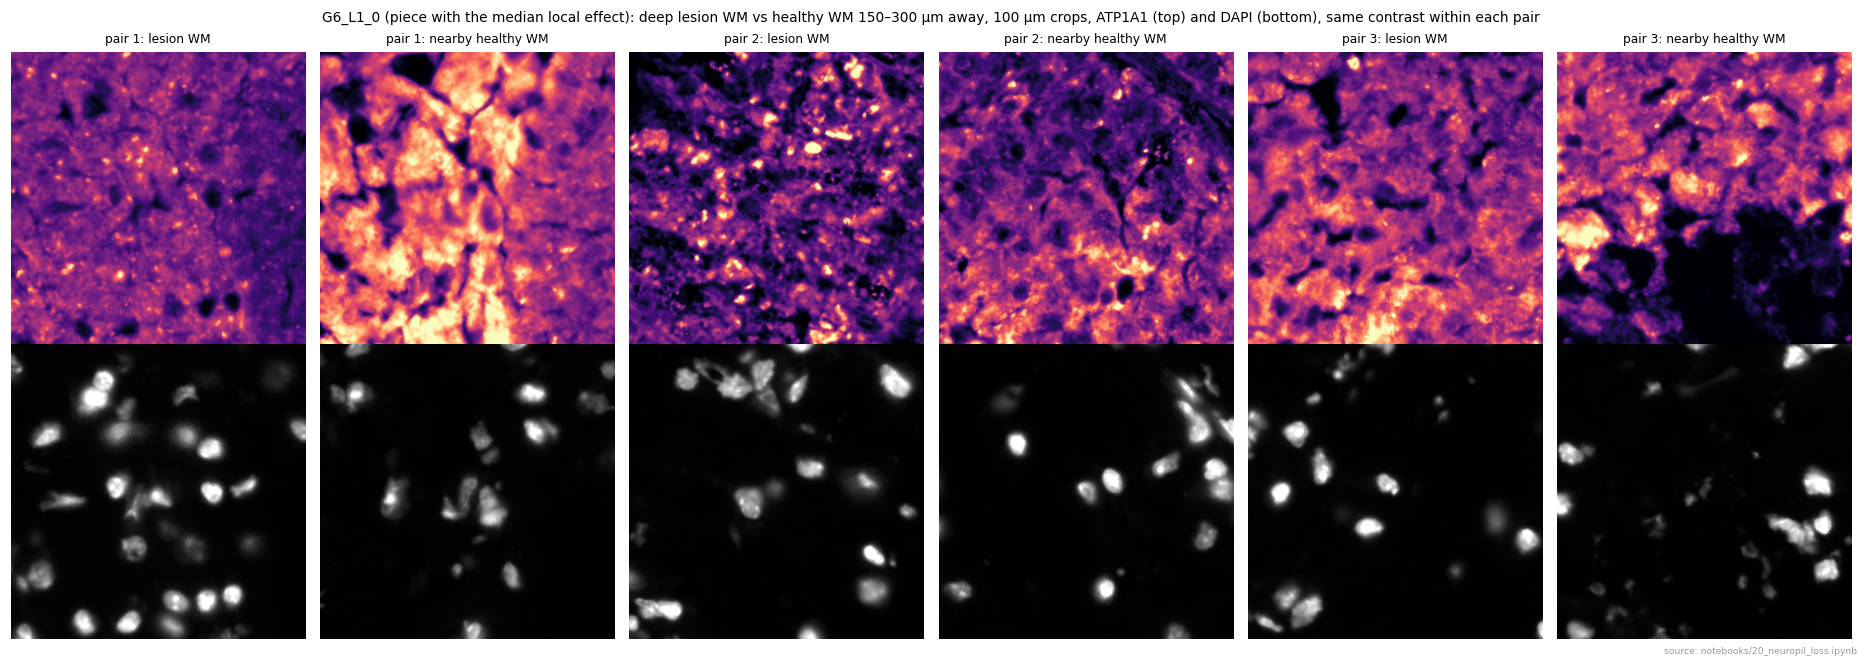

In [18]:
dloc, _ = local_ratio(fa[fa.edge_um > 100], "les_curated", "phys_curated")
pcm = dloc.iloc[(dloc.local_ratio - dloc.local_ratio.median()).abs().argsort().iloc[0]].piece
g = fa[(fa.meta_sample_id == pcm) & (fa.rclass == "WM") & (fa.edge_um > 100)]
Lc, Hc = g[g.les_curated], g[g.phys_curated]
tH = cKDTree(Hc[["x_centroid", "y_centroid"]].to_numpy())
b = XeniumBundle(bundles[str(g.section_id.iloc[0])])
pairs = []
for _, r in Lc.sample(min(200, len(Lc)), random_state=0).iterrows():
    cand = tH.query_ball_point([r.x_centroid, r.y_centroid], 300)
    cand = [i for i in cand if np.hypot(Hc.x_centroid.iloc[i] - r.x_centroid, Hc.y_centroid.iloc[i] - r.y_centroid) >= 150]
    if cand:
        pairs.append((r, Hc.iloc[cand[0]]))
    if len(pairs) == 3:
        break
fig, axs = plt.subplots(2, 6, figsize=(17, 6))
half = 50
for k, (rl, rh) in enumerate(pairs):
    ims = []
    for r in (rl, rh):
        h = int(half / PX)
        img, _, _ = b.read_window(int(r.centroid_y_px) - h, int(r.centroid_x_px) - h, 2 * h, 2 * h)
        ims.append(img)
    hb = np.percentile(np.concatenate([i[1].ravel() for i in ims]), 99.5)
    hd = np.percentile(np.concatenate([i[0].ravel() for i in ims]), 99.5)
    for j, (img, lab) in enumerate(zip(ims, ["lesion WM", "nearby healthy WM"])):
        c = 2 * k + j
        axs[0, c].imshow(np.clip(img[1] / hb, 0, 1), cmap="magma"); axs[1, c].imshow(np.clip(img[0] / hd, 0, 1), cmap="gray")
        axs[0, c].set_title(f"pair {k + 1}: {lab}", fontsize=8)
        axs[0, c].axis("off"); axs[1, c].axis("off")
fig.suptitle(f"{pcm} (piece with the median local effect): deep lesion WM vs healthy WM 150–300 µm away, 100 µm crops, "
             "ATP1A1 (top) and DAPI (bottom), same contrast within each pair", fontsize=9)
fig.tight_layout()
plotting.save_fig(fig, "fair_crops_local_pairs", OUT, SRC)

## 8. Loss or redistribution? Diffuse background vs bright spots
In the crops, lesion WM often shows bright ATP1A1 spots on a dimmer background. The territory *mean* mixes both.
Same local comparison for the territory's median pixel (diffuse neuropil mesh) and 90th-percentile pixel (bright
spots). Loss of diffuse neuropil with brighter spots = redistribution (e.g. Na⁺/K⁺-ATPase redistributed along
damaged/demyelinated axons, or membrane debris), not simple loss.

In [19]:
rows = []
for les, phys, lab in [("les_curated", "phys_curated", "curated niches"), ("les_ctrl", "phys_ctrl", "control-referenced")]:
    d = fa[fa.edge_um > 100]
    for ch, nm in [("bnd", "ATP1A1 territory mean"), ("bndp50", "ATP1A1 diffuse (median pixel)"),
                   ("bndp90", "ATP1A1 bright spots (90th pct pixel)"), ("dapi", "DAPI territory mean")]:
        _, s_ = local_ratio(d, les, phys, ch=ch)
        _, s2 = paired(d, f"{ch}_index", les, phys, "WM", min_n=50)
        rows.append(dict(lesions=lab, readout=nm, local_ratio=s_.get("median_local_ratio"), local_share_below_1=s_.get("share_below_1"),
                         local_p=s_.get("p"), piecewide_ratio=s2.get("median_ratio"), pieces=s_.get("pieces")))
redis = pd.DataFrame(rows)
redis.to_csv(OUT / "loss_or_redistribution.csv", index=False)
redis.round(3)

,lesions,readout,local_ratio,local_share_below_1,local_p,piecewide_ratio,pieces
0,curated niches,ATP1A1 territory mean,0.830,0.980,0.000,0.737,102
1,curated niches,ATP1A1 diffuse (median pixel),0.817,0.990,0.000,0.694,102
2,curated niches,ATP1A1 bright spots (90th pct pixel),0.851,0.990,0.000,0.793,102
3,curated niches,DAPI territory mean,0.995,0.529,0.440,1.075,102
4,control-referenced,ATP1A1 territory mean,0.967,0.721,0.000,0.883,104
5,control-referenced,ATP1A1 diffuse (median pixel),0.958,0.788,0.000,0.860,104
6,control-referenced,ATP1A1 bright spots (90th pct pixel),0.992,0.606,0.289,0.939,104
7,control-referenced,DAPI territory mean,1.197,0.038,0.000,1.449,104


## Findings (revised after sections 7–8)

> **Correction — part of the piece-wide effect was anatomy.** Comparing lesion WM with *all* healthy WM of a piece
> mixes tracts that differ in ATP1A1 density. Against healthy WM **within 150 µm** the loss is ×0.83 (curated lesions,
> 98 % of 102–105 pieces below 1, deep cells the same; DAPI ×1.00), versus ×0.73 piece-wide. About 40 % of the first
> estimate was location; a ~17 % local loss remains and is very consistent. With the broader control-referenced
> lesion calls the local loss is only ~3 % (×0.97), so it belongs to the dense lesion cores.
>
> **Loss, with clumps.** The diffuse neuropil mesh (median pixel) is ×0.82 locally and the bright spots (90th
> percentile) ×0.85, so both are lower on average. Crops show a dimmer mesh, sometimes with bright clumps on top
> (possibly swollen axons or debris), which is why lesions can *look* bright in places.
>
> **Overall:** a real, local, ATP1A1-specific loss of ~17 % in dense white-matter lesion cores, robust to crowding,
> composition and the tissue surface; smaller than first reported (×0.73) and not visible in every field.